**Table of contents**<a id='toc0_'></a>    
- [How to determine energy transfer efficiencies](#toc1_)    
  - [Simple example](#toc1_1_)    
  - [Efficiencies vs distance](#toc1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[How to determine energy transfer efficiencies](#toc0_)

In [ ]:
import warnings
import numpy as np

import fluopy.figure as fi
import fluopy.formulas as fo
import fluopy.miscellaneous as mi

%load_ext autoreload
%autoreload 2


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

for package in [fi, fo, mi]:
    print(f"{package.__name__} version: {package.__version__}")

## <a id='toc1_1_'></a>[Simple example](#toc0_)

In [ ]:
efficiency = fo.calculate_fret_efficiency(fret_rate=1e8, fluorescence_lifetime=1e-9)
print(f"{efficiency:.2e}")

9.09e-02


## <a id='toc1_2_'></a>[Efficiencies vs distance](#toc0_)

In [3]:
J_1 = 1e15
J_2 = 1e10
orient = 2 / 3
emission_rate = 1e8
refractive_index = 1
tau_fl = 1e-9

rates_J1 = []
distances = np.arange(1, 12, 1)
for distance in distances:
    rate = fo.calculate_fret_rate(
        distance=distance,
        emission_rate=emission_rate,
        spectral_overlap_integral=J_1,
        dipole_orientation_factor=orient,
        refractive_index=refractive_index,
    )
    rates_J1.append(rate)

efficiencies_J1 = []
for rate in rates_J1:
    e = fo.calculate_fret_efficiency(rate, fluorescence_lifetime=tau_fl)
    efficiencies_J1.append(e)

rates_J2 = []
distances = np.arange(1, 12, 1)
for distance in distances:
    rate = fo.calculate_fret_rate(
        distance=distance,
        emission_rate=emission_rate,
        spectral_overlap_integral=J_2,
        dipole_orientation_factor=orient,
        refractive_index=refractive_index,
    )
    rates_J2.append(rate)

efficiencies_J2 = []
for rate in rates_J2:
    e = fo.calculate_fret_efficiency(rate, fluorescence_lifetime=tau_fl)
    efficiencies_J2.append(e)

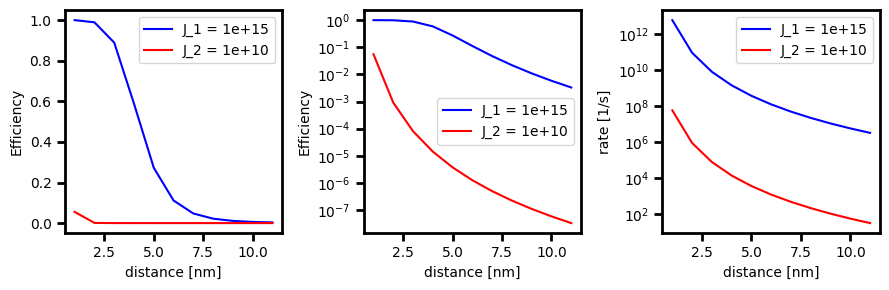

In [4]:
axes = fi.universal_figure(
    data=[distances, efficiencies_J1],
    ylabel="Efficiency",
    xlabel="distance [nm]",
    ncols=3,
    fontsize=10,
    fig_width=9,
    label=f"{J_1 = :.0e}",
    legend=True,
)
fi.universal_figure(
    data=[distances, efficiencies_J1],
    ylabel="Efficiency",
    xlabel="distance [nm]",
    fontsize=10,
    axes=axes[0, 1],
    yscale="log",
    label=f"{J_1 = :.0e}",
    legend=True,
)
fi.universal_figure(
    type_="line",
    data=[distances, rates_J1],
    ylabel="rate [1/s]",
    xlabel="distance [nm]",
    yscale="log",
    legend=True,
    label=f"{J_1 = :.0e}",
    axes=axes[0, 2],
    fontsize=10,
)
fi.universal_figure(
    data=[distances, efficiencies_J2],
    ylabel="Efficiency",
    xlabel="distance [nm]",
    axes=axes[0, 0],
    fontsize=10,
    fig_width=9,
    label=f"{J_2 = :.0e}",
    legend=True,
    color="red",
)
fi.universal_figure(
    data=[distances, efficiencies_J2],
    ylabel="Efficiency",
    xlabel="distance [nm]",
    fontsize=10,
    axes=axes[0, 1],
    yscale="log",
    label=f"{J_2 = :.0e}",
    legend=True,
    color="red",
)
fi.universal_figure(
    type_="line",
    data=[distances, rates_J2],
    ylabel="rate [1/s]",
    xlabel="distance [nm]",
    yscale="log",
    legend=True,
    label=f"{J_2 = :.0e}",
    axes=axes[0, 2],
    fontsize=10,
    color="red",
)
figure = mi.get_figure(axes)
figure.tight_layout()